## Théorie :

2 principales méthodes :
* `fit()` pour entrainer le modele sur les données étiquetées (X,y)
* `predict()` pour prédire yhat à partir de X  

Les principaux paramèrtes :
* `g` : Fonction d'activation appliquée à la sortie de chaque neuronne afin d'introduire une non-linéarité dans le réseau
* `LR` : Learning Rate - Paramètre controlant l'amplitude des modifications appliqués aux poids et aux biais lors de leur mise à jour. Un learning rate trop élevé peut rendre l'apprentissage instable, tandis que trop faible le ralentit.
* `w` : Poids du système - Paramètres appris par le réseau qui déterminent l'influence des sorties des neurones d'une couche à l'autre. Chaque connexion entre deux neurones possède un poids.  
Pour une couche $l$ : $\quad \displaystyle W^(l) ∈ R^{n_{l-1}*n_l}$ 
* `architecture` : L'architecture du MLP définit le nombre de neuronnes de chacune des couches. La couche d'entrée est déterminée implicitement par le nombre de feature de  $X$ `X.shape[1]`
* `B` : le biais - Paramètre appris associés à chaque neurone. Ils sont ajoutés à la somme pondérée avant l'application de g. Ils permettent notamment de décaler g indépendamment des valeurs d'entrée.  
Pour un couche $l$ : $b^{l} ∈ R^{ n_l}$
* `X` : Matrice contenant les exemples. Chaque ligne correspond à un exemple et chaque colonne un attribut
* `y` : Valeur réelle associé à chaque exemple, utilisée pour calculer la Loss function
* `ŷ` : Label prédit en sortie du MLP à partir de $X$

## Forward Propagation :
En entrée, le neuronne $k$ fait la somme pondérée des sorties des neurones $j$ :
$$
a_k = \sum_{j=1}^{d} w_{jk}\;z_j + b_k
\quad | \quad puis \;
z_k = g(a_k)
$$

* $a_k$ : entrée du neuronne k
* $w_{jk}$ : poids entre le neuronne j et k
* $z_j$ : sorti du neuronne j de la couche précédente
* $b_k$ : biais du neurone $k$
* $z_k$ : sorti du neuronne $k$ après activation

**En Matricielle** on obtient : 
$$
a^{(l)} = W^{(l)}z^{(l-1)}+b^{(l)} \quad puis \; z^{(l)} = g(a^{(l)})
$$

### Activation function :
La sortie passe par une fonction d'activation pour introduire une non-linéarité :
| Fonction | equation | dérivée |
|:---:|:---:|:---:|
| **Sigmoïde** | $\displaystyle g(a)=\frac{1}{1+e^{-a}}$ | $\displaystyle g'(a)=g(a)(1-g(a))$ |
| **ReLu** | $\displaystyle g(a)=\max(0,a)$ | $\displaystyle g'(a)=\begin{cases}0 & \text{si } a<=0\\1 & \text{si } a>0\end{cases}$ |
| **Tanh** | $\displaystyle g(a)=\frac{e^{a}-e^{-a}}{e^{a}+e^{-a}}$ | $\displaystyle g'(a)=1-g(a)^2$ |  

Pour ReLu, dérivée en 0 n'existe pas. On choisit $g'(0) = 0$

## Loss Function :
Maintenant que le réseau peut generer des sorties, l'étape suivante est de calculer la Loss en utilisant la Loss function.  
En apprentissage supervisé cela revient à comparer la sortie avec le label.

1. Pour un problème de classification classique on utilise la fonction de perte `binary cross-entropy (BCE)` :

$$
\displaystyle
BCE = - \frac{1}{N} \sum_{i=1}^{N} \; [ y_i log(\hat{y}_i) + (1-y_i)log(1-\hat{y}_i)]
$$
* Pour une classification binaire
* Pour une sortie multi-label, avec un BCE par sortie

2. Pour un problème de régression, on utilise plutot le `Mean squarred error (MSE)`:
$$
\displaystyle
MSE = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
$$

* $y_i$ : le label réel
* $\hat{y}_i$ : le label prédit
* $N$ : nombre d'exemple

## Back Propagation : 
L'objectif de l'entraînement d'un MLP est de minimiser la fonction de perte en ajustant progressivement les poids et les biais du réseau. Pour cela, on utilise la rétropropagation du gradient (backpropagation).
1. **Calcul de la perte** : la fonction de perte compare la prédiction du réseau $\hat{y}$ avec le label réel $y$ : 
$$
\frac{\partial L}{\partial a^{(n)}} =  \delta^{(n)}
$$  
* pour le couple BCE / Sigmoide : $\delta^{(n)} = \hat{y} - y$
* pour le couple MSE / Identité : $\delta^{(n)} = 2(\hat{y} - y)$

2. **Rétropropagation** : les gradients de la fonction de perte par rapport à chaque poids et chaque biais sont calculés en utilisant la règle de dérivation en chaîne. Le calcul est effectué en remontant de la couche de sortie vers les couches précédentes. 
$$
\delta^{(l-1)} = \delta^{(l)} @ W^{(l).T} g'(a^{(l-1)})
$$
3. **Descente de gradient** : les poids et les biais sont ensuite mis à jour dans la direction opposée au gradient afin de réduire la fonction de perte :
$$
w^{(l)} \leftarrow w^{(l)}-\eta\frac{\partial L}{\partial w^{(l)}} = w^{(l)}-\eta z^{(l-1).T} @ \delta^{(l)}
$$

$$
b^{(l)} \leftarrow b^{(l)}-\eta\frac{\partial L}{\partial b^{(l)}} = b^{(l)}-\eta\delta^{(l)}
$$

$w$ : le poids
$b$ : le biais
$\eta$ : le learning rate
$\frac{\partial L}{\partial w}$ : gradient de la fonction de perte par rapport au poids
$\frac{\partial L}{\partial b}$ : gradient de la fonction de perte par rapport au biais

## Optimisation :

Les MLP reposent sur des algo d'optimisation pour améliorer itérativement les poids et biais durant l'entrainement. Les méthodes d'optimisation populaires incluent notament :  
* La **descente Stochastique du gradient (SGD)** : MAJ des poids en chaîne = 1 par 1 sur tout les échantillons ou par petit batch

Equation de l'hyper-plan :

## **Fonction linéaire de sortie**

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split


In [39]:
class MLP:
    def __init__(self, architecture, g = False, loss = False, g_predict = 'label', LR = 0.1, w = None, biais = None, epoch = 10, batch = 10): 
        '''
        Initialisation du modèle
        architecture : [n1, ..., n-1, n] - n1 à n-1 couches intermédiaires, n couche de sortie. Couche d'entrée implicites X.shape[1]
        g : fontion d'activation non linéaire {'sigmoide', 'ReLu', 'tanh'}
        g_predict : fonction de formatage des output dans predict | linéaire ou discrète 
        LR : Learning Rate - Trop petit = lent => pas le temps de se stabiliser | Trop haut = oscille autour de la stabilité
        w : Matrice des poids
        biais : Matrice des biais
        epoch : nombre de cycle d'entrainement
        batch : fraction l'echantillon dans le fit 
            - Descente totale du gradiant = X.Shape[0]
            - Descente stochastique du gradient (SGD) = 1
            - Par batch = entier dans [1,X.Shape[0]]
        '''

        def softmax(a):
            e = np.exp(a - np.max(a, axis=1, keepdims=True)) # soustraire le max = trick standard, ne change pas le résultat mathématique
            return e / np.sum(e, axis=1, keepdims=True)
        def sigmoide(a):
            return 1/(1+np.exp(-a))
        
        self.f_dict = {
            "sigmoide" : (lambda a: sigmoide(a), lambda a: sigmoide(a)*(1-sigmoide(a))),
            "ReLu" : (lambda a: np.maximum(0,a), lambda a: np.where(a <=0,0,1)),
            "tanh" : (lambda a: np.tanh(a), lambda a: 1 - np.tanh(a)**2)
        }

        self.loss_dict = {
            'BCE': (lambda a: sigmoide(a), lambda yhat, y: yhat - y),         # sigmoide / BCE
            'MSE': (lambda a: a, lambda yhat, y: 2 * (yhat - y)),             # identite / MSE
            'CCE': (softmax, lambda yhat, y: yhat - y)                        # CCE : même formule que BCE, mais yhat/y sont des matrices (batch, K)
        }

        self.classes = (0,1)
        self.biais = biais                                 
        self.architecture = architecture                             
        self.g = g      
        self.loss = loss
        self.g_predict = g_predict                             
        self.LR = LR                                      
        self.w = w
        self.epoch = epoch
        self.batch = batch


    def forward(self,X):
        '''
        Calculer un yhat en stockant tout les a(l) et z(l) de 1 à n
        '''
        n = len(self.architecture)
        self.a_history = []
        self.z_history = [np.copy(X)]

        for k in range(n-1):
            self.a_history.append(self.z_history[-1] @ self.w[k] + self.biais[k])
            if k < n-2:
                self.z_history.append(self.g[0](np.array(self.a_history[-1])))
            else:
                self.z_history.append(self.loss_dict[self.loss][0](self.a_history[-1]))
        
        return self.z_history[-1]


    def update(self, y_batch):
        n = len(self.architecture)

        delta = [0]*(n-1)                                                                       #Initialisation avec couple BCE/sigmoide / MSE/identite / CCE/softmax
        if self.loss == 'CCE':
            delta[n-2] = self.loss_dict[self.loss][1](self.z_history[-1], y_batch)                      # delta_n = yhat - y pour CCE/softmax | pas de reshape car on peut avoir des matrices y
        else:
            delta[n-2] = self.loss_dict[self.loss][1](self.z_history[-1], y_batch.reshape(-1,1))        # delta_n = yhat - y pour BCE/sigmoide et MSE/identite
        
        for i in range(n-2):  # Puis propagation : delta_(l-1) = delta_l @ w_l.T * g'(a_(l-1))          # delta_n = 2(yhat - y) pour MSE/idente
            delta[n-3-i] = (delta[n-2-i] @ self.w[n-2-i].T) * self.g[1](self.a_history[n-3-i]) 

        for i in range(n-1):  # Pour finir les maj : avec des normalisation par le nombre d'elements
            self.w[i] = self.w[i] - self.LR * self.z_history[i].T @ (delta[i] / len(y_batch))                 # w_l <- \eta * z_(l-1).T @ delta_l
            self.biais[i] = self.biais[i] - self.LR * (np.sum(delta[i], axis=0, keepdims=True)/ len(y_batch)) # b_l <- \eta * delta_l


    def fit(self, x, Y):
        X, y = np.copy(x), np.copy(Y)

        if self.g == False or self.loss == False:  #Rien de renseigner on choisit seul
            if len(np.unique(y)) == 2:                                  # On part sur BCE
                self.g = 'sigmoide' if self.g == False else self.g
                self.loss = 'BCE' if self.loss == False else self.loss
            elif (len(np.unique(y)) > 2) and (len(np.unique(y)) < len(y)/2):  # On considère CCE
                self.g = 'sigmoide' if self.g == False else self.g
                self.loss = 'CCE' if self.loss == False else self.loss
            else:                                                       # Trop de classe = continue ?
                self.g = 'sigmoide' if self.g == False else self.g
                self.loss = 'MSE' if self.loss == False else self.loss

        self.g = self.f_dict[self.g]

        if self.loss == 'BCE': # Si on est en binaire
            if self.architecture[-1] != 1:
                print(f'diminution du nombre de neurone de sorti de {self.architecture[-1]} à 1')
                self.architecture[-1] = 1
            self.classes = (y.min(), y.max())# stocker les classes
            y = np.where(y == y.min(), 0, 1) # Normaliser les y entrees a {0,1}

        if self.loss == 'CCE':
            self.classes = np.unique(y)
            assert len(self.classes) == self.architecture[-1], "le nombre de neurones de sortie doit égaler le nombre de classes"
            y = (y.reshape(-1,1) == self.classes).astype(float)   # matrice one-hot (N, K), via broadcasting


        n = len(self.architecture)

        if self.w is None:
            self.w = []
            for k in range(n-1):
                n_in, n_out = self.architecture[k], self.architecture[k+1]              # Critere  d'initialisation de Xavier(Glorot) a 2 but :
                limite = np.sqrt(6 / (n_in + n_out))                                       # Préserver la variation d'activation durant forward
                self.w.append(np.random.uniform(-limite, limite, size=(n_in, n_out)))      # PRéserver variance gradiant durant backward
    
        if self.biais is None:
            self.biais = []
            for k in range(n-1):
                n_out = self.architecture[k+1]
                self.biais.append(np.zeros((1, n_out)))

        if self.batch > X.shape[0]:
            raise ValueError(f"Taille du batch ({self.batch}) supérieur aux nombres d'échantillons ({X.shape[0]})")

        for _ in range(self.epoch):
            index = np.arange(X.shape[0])
            np.random.shuffle(index)
            for k in range( X.shape[0] // self.batch ):
                i_inf = k*self.batch
                i_sup = i_inf + self.batch
                X_batch = X[index[i_inf:i_sup],:]
                y_batch = y[index[i_inf:i_sup]]

                self.forward(X_batch)
                self.update(y_batch)


    def predict(self, X):
        '''
        Calcule la sortie du réseau et la formate selon la tâche (self.loss)
        et le format demandé (self.g_predict) :
        - 'proba' : renvoie les probabilités (BCE : 1 colonne, CCE : 1 colonne par classe)
        - 'label' : renvoie les labels d'origine (ceux fournis à fit())
        - MSE     : g_predict est ignoré, seule une valeur continue a du sens
        '''
        yhat = self.forward(X)

        if self.loss == 'MSE':  # sortie continue, aucun formatage n'a de sens ici
            return yhat
        
        elif self.loss == 'BCE':
            if self.g_predict == 'proba':
                return np.hstack([1 - yhat, yhat])  # colonne 0 = P(classes[0]), colonne 1 = P(classes[1])
            elif self.g_predict == 'label':
                label_binaire = np.where(yhat < 0.5, 0, 1)
                return np.where(label_binaire == 0, self.classes[0], self.classes[1])

        elif self.loss == 'CCE':
            if self.g_predict == 'proba':
                return yhat  # déjà une matrice (N, K) de probabilités softmax
            elif self.g_predict == 'label':
                indice_classe = np.argmax(yhat, axis=1)
                return self.classes[indice_classe]

        raise ValueError(f"Combinaison loss={self.loss} / g_predict={self.g_predict} non gérée")

    def scoring(self, y_hat, y, score = True, Cmatrix = False):
        def conf_mat(y_hat, y):
            return np.array([[np.sum( (y_hat == i) & (y == j) ) for i in self.classes] for j in self.classes])


        if self.loss == 'BCE' or self.loss == 'MSE':
            n_output = self.architecture[-1]
            y_hat = np.array(y_hat).reshape(-1,n_output)
            y = np.array(y).reshape(-1,n_output)
        

        if self.loss == 'BCE':
            TP = np.sum((y_hat == self.classes[1]) & (y == self.classes[1]))
            FN = np.sum((y_hat == self.classes[0]) & (y == self.classes[1])) 
            FP = np.sum((y_hat == self.classes[1]) & (y == self.classes[0]))
            TN = np.sum((y_hat == self.classes[0]) & (y == self.classes[0]))
                  
            score = {
                'accuracy' : (TP + TN) / (TP + TN + FP + FN),
                'recall' : np.nan if (TP + FN == 0) else (TP / (TP + FN)) ,
                'precision' : np.nan if (TP + FP == 0) else (TP / (TP + FP)),
                'FPR' : np.nan if (FP + TN == 0) else (FP / (FP + TN))
                }
        
            return score, conf_mat(y_hat, y)

        if self.loss == 'CCE':
            Cmatrix = conf_mat(y_hat, y)
            sc = []
            for idx, k in enumerate(self.classes):
                TP_i = Cmatrix[idx,idx]
                FN_i = np.sum(Cmatrix[idx,:]) - TP_i
                FP_i = np.sum(Cmatrix[:,idx]) - TP_i
                TN_i = np.sum(Cmatrix) - TP_i - FP_i - FN_i
                sc.append([
                    TP_i, FN_i, FP_i, TN_i 
                ])
            
            sc = np.array(sc)    
            TP = np.sum(sc[:,0])
            FN = np.sum(sc[:,1])
            FP = np.sum(sc[:,2])
            TN = np.sum(sc[:,3])

            score = {
                            'accuracy' : (TP + TN) / (TP + TN + FP + FN),
                            'recall' : np.nan if (TP + FN == 0) else (TP / (TP + FN)) ,
                            'precision' : np.nan if (TP + FP == 0) else (TP / (TP + FP)),
                            'FPR' : np.nan if (FP + TN == 0) else (FP / (FP + TN))
                            }
            
            return score, Cmatrix

        if self.loss == 'MSE':
            n = len(y)
            MAE = np.sum(np.abs(y_hat - y))/n                             # Mean Absolute Error
            RMSE = np.sqrt( np.sum((y_hat-y)**2) / n )                    # Root-Mean-Square Error
            R2 = 1 - np.sum((y - y_hat)**2) / np.sum((y - y.mean())**2)

            return MAE, RMSE, R2

        

    def mermaid(self, learn=False):
        n_features = self.architecture[0]
        code = ["```mermaid", "flowchart LR"]

        couches = []

        # Couche d'entrée
        entree = []
        for i in range(n_features):
            nom = f"x{i+1}"
            entree.append(nom)
            code.append(f"    {nom}((x{i+1}))")
        couches.append(entree)

        # Couches du réseau
        compteur = 1
        for n_neurones in self.architecture[1:]:
            couche = []

            for _ in range(n_neurones):
                nom = f"n{compteur}"
                couche.append(nom)
                code.append(f"    {nom}((n{compteur}))")
                compteur += 1

            couches.append(couche)

        # Connexions
        for l in range(len(couches) - 1):

            for i, source in enumerate(couches[l]):
                for j, cible in enumerate(couches[l + 1]):

                    if learn:
                        poids = self.w[l][i][j]

                        label = (
                            f"w<sup>{l+1}</sup><sub>"
                            f"{source[1:]},{cible[1:]}</sub> = {poids:.3f}"
                        )

                    else:
                        label = (
                            f"w<sup>{l+1}</sup><sub>"
                            f"{source[1:]},{cible[1:]}</sub>"
                        )

                    code.append(
                        f"    {source} -->|{label}| {cible}"
                    )

        code.append("```")

        display(Markdown("\n".join(code)))

In [5]:
mod = MLP([3,2,2])
mod.mermaid(False) # Print le shema du reseau de neurone
# Si le graph est bugge, clear cell (alt+del) output puis relancer

```mermaid
flowchart LR
    x1((x1))
    x2((x2))
    x3((x3))
    n1((n1))
    n2((n2))
    n3((n3))
    n4((n4))
    x1 -->|w<sup>1</sup><sub>1,1</sub>| n1
    x1 -->|w<sup>1</sup><sub>1,2</sub>| n2
    x2 -->|w<sup>1</sup><sub>2,1</sub>| n1
    x2 -->|w<sup>1</sup><sub>2,2</sub>| n2
    x3 -->|w<sup>1</sup><sub>3,1</sub>| n1
    x3 -->|w<sup>1</sup><sub>3,2</sub>| n2
    n1 -->|w<sup>2</sup><sub>1,3</sub>| n3
    n1 -->|w<sup>2</sup><sub>1,4</sub>| n4
    n2 -->|w<sup>2</sup><sub>2,3</sub>| n3
    n2 -->|w<sup>2</sup><sub>2,4</sub>| n4
```

In [ ]:
def test_shapes_coherentes():
    """Vérifie que toutes les couches ont des poids/biais de la bonne forme après fit."""
    mod = MLP([2,4,3,1], loss='BCE', epoch=5, batch=10)
    X = np.random.randn(50, 2)
    y = np.random.choice([-1,1], 50)
    mod.fit(X, y)
    assert mod.w[0].shape == (2,4)
    assert mod.w[1].shape == (4,3)
    assert mod.w[2].shape == (3,1)
    assert mod.biais[0].shape == (1,4)
    print("OK : formes des poids/biais")

def test_bce_label_retombe_sur_classes_dorigine():
    mod = MLP([2,4,1], loss='BCE', g_predict='label', epoch=200, batch=10)
    X, y = make_blobs(n_samples=100, centers=[[-2,-2],[2,2]], random_state=0)
    y = y*2-1  # classes {-1, 1}
    mod.fit(X, y)
    preds = mod.predict(X)
    assert set(np.unique(preds)) <= {-1, 1}, "predict() doit renvoyer les classes d'origine"
    print("OK : BCE/label")

def test_cce_proba_somme_a_1():
    mod = MLP([2,4,3], loss='CCE', g_predict='proba', epoch=200, batch=10)
    X, y = make_blobs(n_samples=150, centers=3, random_state=0)
    mod.fit(X, y)
    probas = mod.predict(X)
    assert probas.shape == (150, 3)
    assert np.allclose(probas.sum(axis=1), 1.0), "les probabilités softmax doivent sommer à 1"
    print("OK : CCE/proba")

test_shapes_coherentes()
test_bce_label_retombe_sur_classes_dorigine()
test_cce_proba_somme_a_1()

## Test BCE / CCE

architecture, g = 'sigmoide', loss = 'BCE', g_predict = 'proba', LR = 0.1, w = None, biais = None, epoch = 10, batch = 10

diminution du nombre de neurone de sorti de 2 à 1
{'accuracy': np.float64(0.9454545454545454), 'recall': np.float64(0.9627329192546584), 'precision': np.float64(0.9281437125748503), 'FPR': np.float64(0.07100591715976332)}
{'accuracy': np.float64(0.9959595959595959), 'recall': np.float64(0.9939393939393939), 'precision': np.float64(0.9939393939393939), 'FPR': np.float64(0.0030303030303030303)}
{'accuracy': np.float64(1.0), 'recall': np.float64(1.0), 'precision': np.float64(1.0), 'FPR': np.float64(0.0)}
{'accuracy': np.float64(1.0), 'recall': np.float64(1.0), 'precision': np.float64(1.0), 'FPR': np.float64(0.0)}


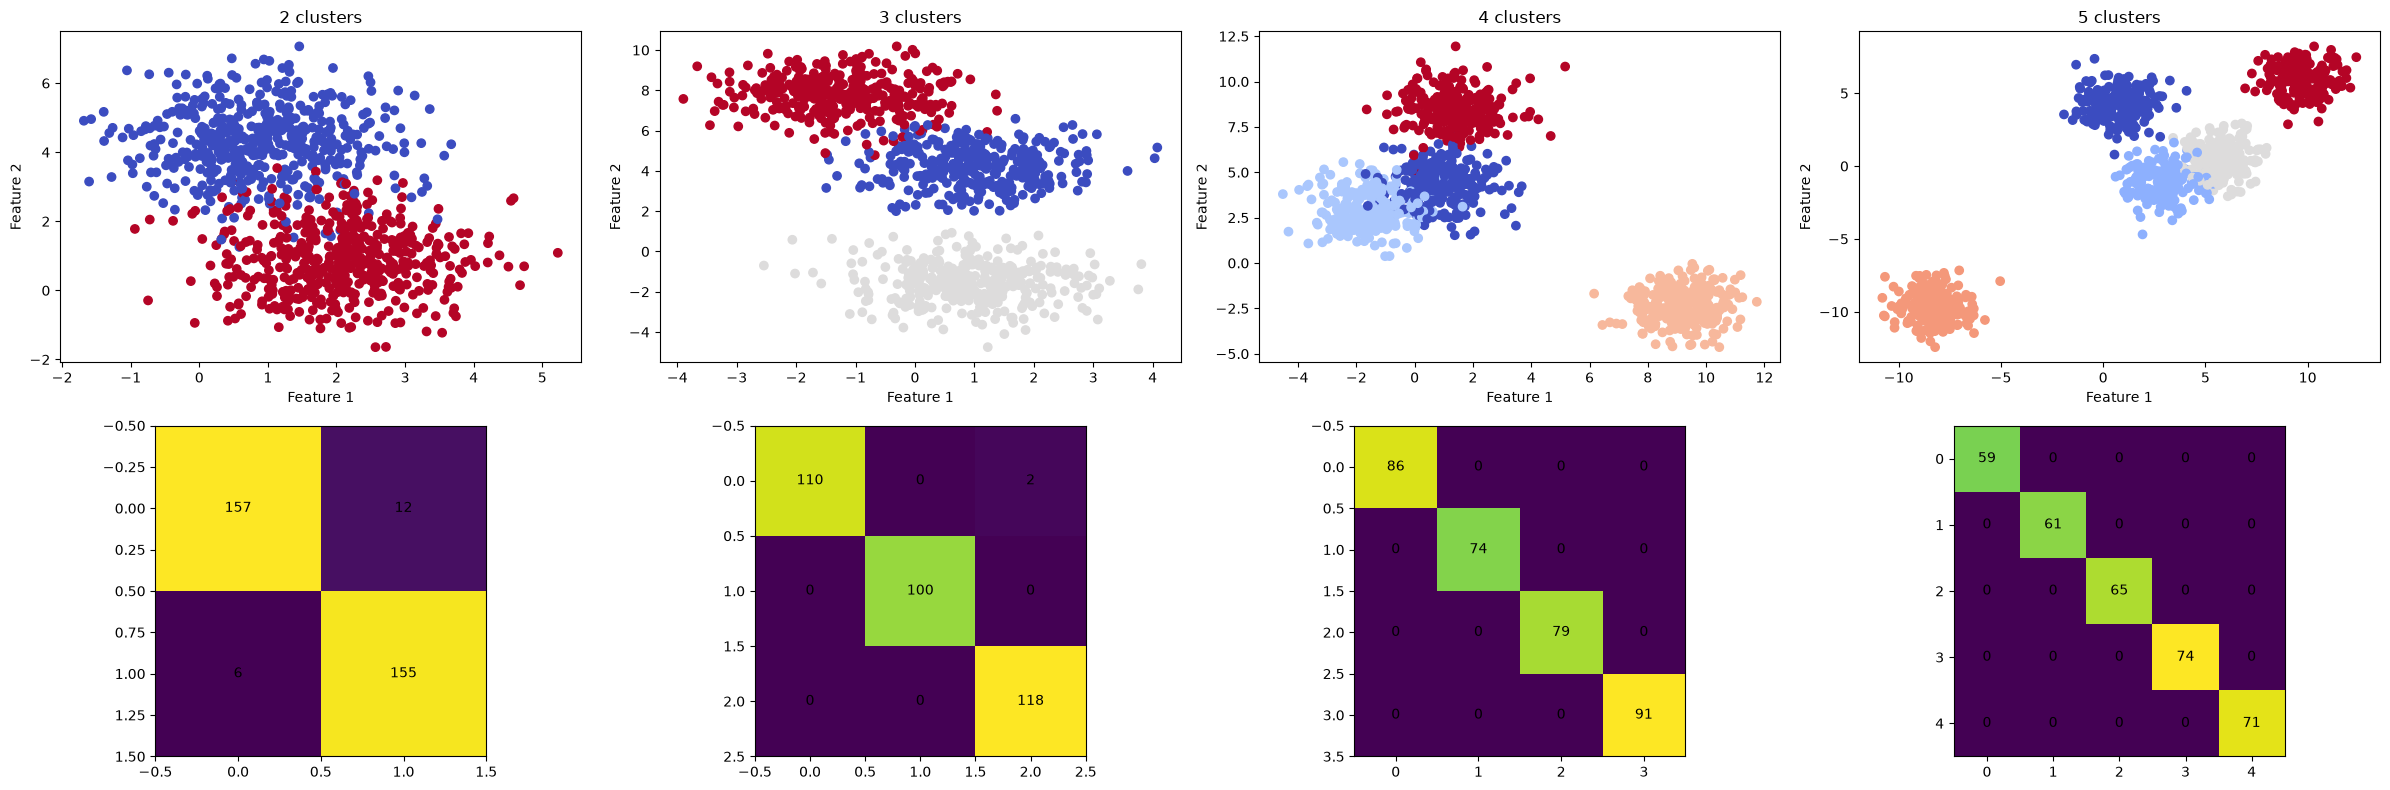

In [12]:
L = [2, 3, 4, 5]

fig, axes = plt.subplots(2, len(L), figsize=(24, 8))

for i, k in enumerate(L):
    X, y = make_blobs(n_samples=1000,centers=k,n_features=k,random_state=0)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)

    axes[0][i].scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm")
    axes[0][i].set_title(f"{k} clusters")
    axes[0][i].set_xlabel("Feature 1")
    axes[0][i].set_ylabel("Feature 2")

    mod = MLP([X.shape[1],4,4,4,len(np.unique(y))], g_predict='label', LR = 0.4, epoch = 1000)
    mod.fit(X_train, y_train)
    yhat = mod.predict(X_test)
    score, cm = mod.scoring(yhat, y_test)

    axes[1][i].imshow(cm)
    for a in range(cm.shape[0]):
        for b in range(cm.shape[1]):
            axes[1][i].text(b, a, cm[a, b], ha="center", va="center", color="black")

    print(score)

plt.tight_layout()
plt.show()

## Test MSE

sigmoide MAE : 0.1456 RMSE : 0.2139 R² : 0.9067
tanh MAE : 0.0788 RMSE : 0.1035 R² : 0.9782
ReLu MAE : 0.1503 RMSE : 0.192 R² : 0.9249


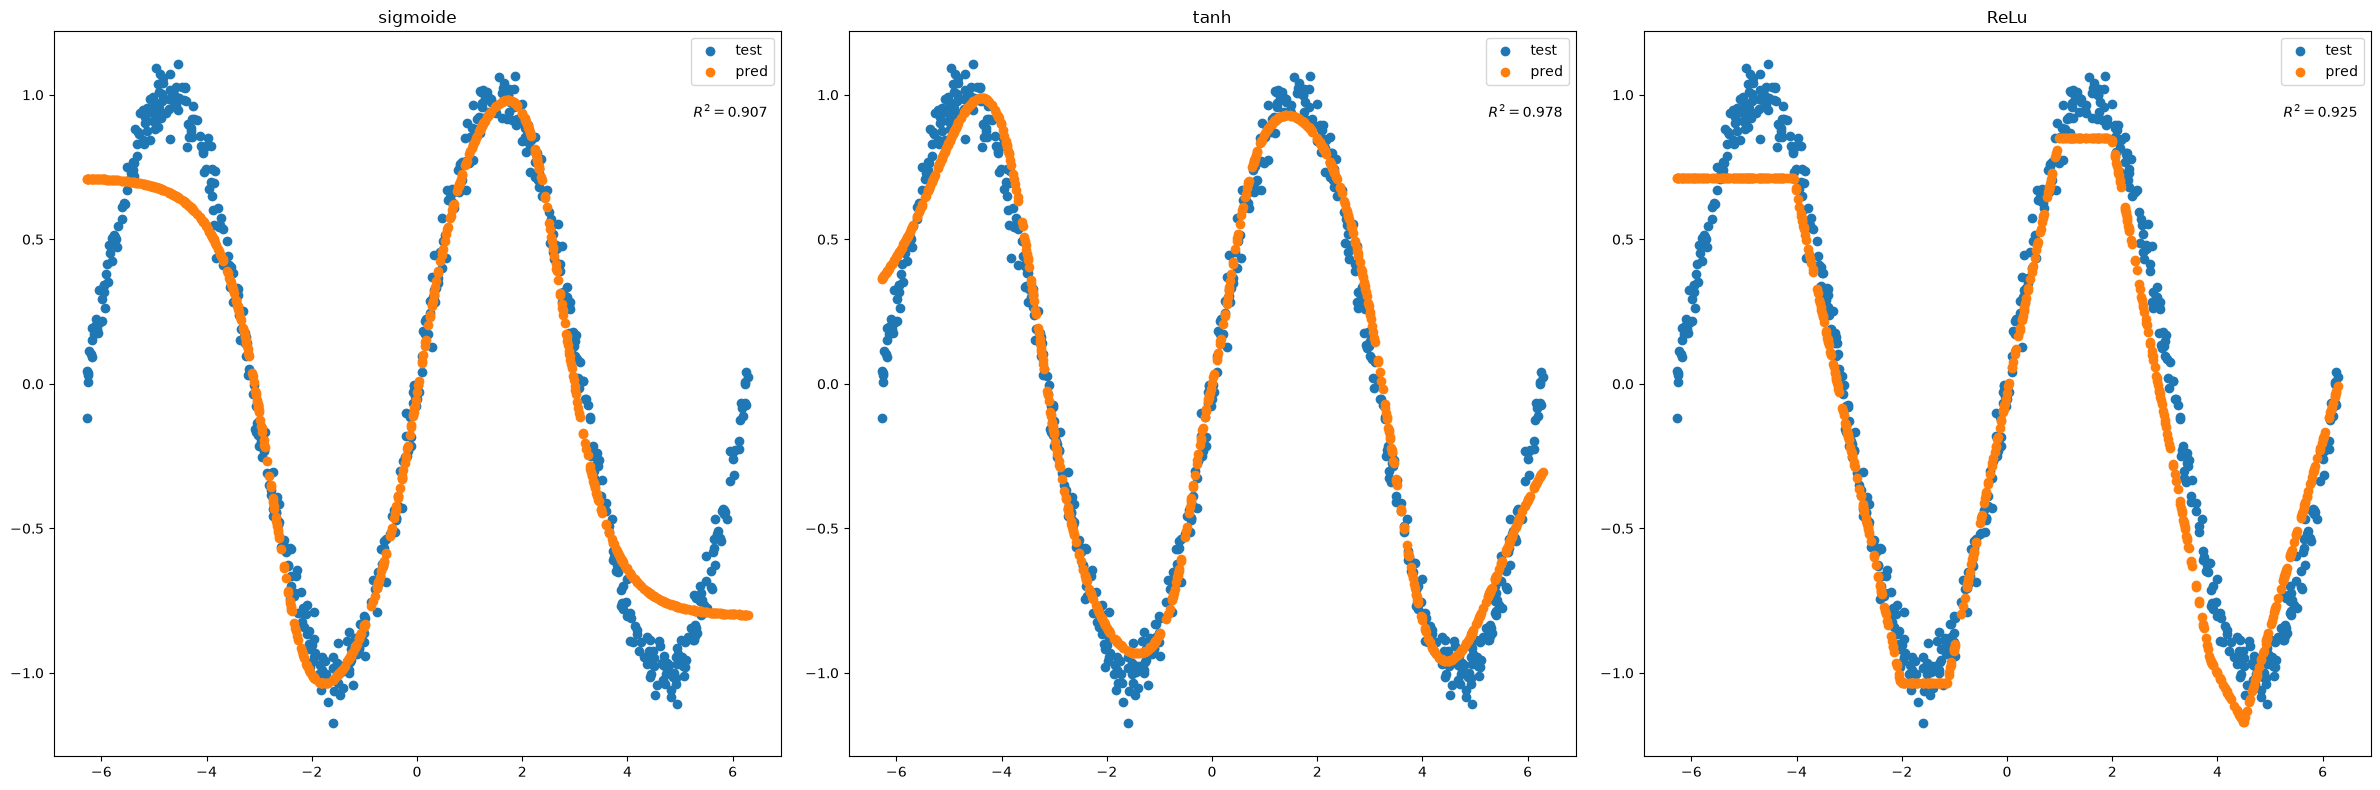

'\nFrequement le Relu donne R² = 0, parfois R² > 0.9 ==> Très instable\nrésultat tanh souvent > Sigmoide >>> ReLu\nPasser de LR 0.2 à 0.1 fait pour tanh R² de 0.92 à 0.98\n'

In [ ]:
X = np.linspace(-2 * np.pi, 2 * np.pi, 2000).reshape(-1, 1)
y = np.sin(X[:, 0]) + 0.05 * np.random.randn(X.shape[0])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)

L = ['sigmoide', 'tanh', 'ReLu']
fig, axes = plt.subplots(1, len(L), figsize=(24, 8))

for k, activation in enumerate(L):
    mod = MLP(
        [X.shape[1],3,3,1],
        g=activation,
        loss='MSE',
        epoch=100,
        LR=0.1
    )
    mod.fit(X_train, y_train)
    yhat = mod.predict(X_test)

    score = mod.scoring(yhat, y_test)
    print(activation, 'MAE :', np.round(score[0],4),'RMSE :', np.round(score[1],4),'R² :', np.round(score[2],4))

    axes[k].scatter(X_test, y_test, label='test')
    axes[k].scatter(X_test, yhat, label='pred')
    axes[k].set_title(activation)
    axes[k].text(
       0.88, 0.9,
        rf'$R^2 = {score[2]:.3f}$',
        transform=axes[k].transAxes,
        verticalalignment='top',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
    )
    axes[k].legend()

plt.tight_layout()
plt.show()

'''
Frequement le Relu donne R² = 0, rarement on a R² > 0.9 ==> Très instable ++
résultat tanh souvent > Sigmoide >>> ReLu
Passer de LR 0.2 à 0.1 fait pour tanh R² de 0.92 à 0.98
'''

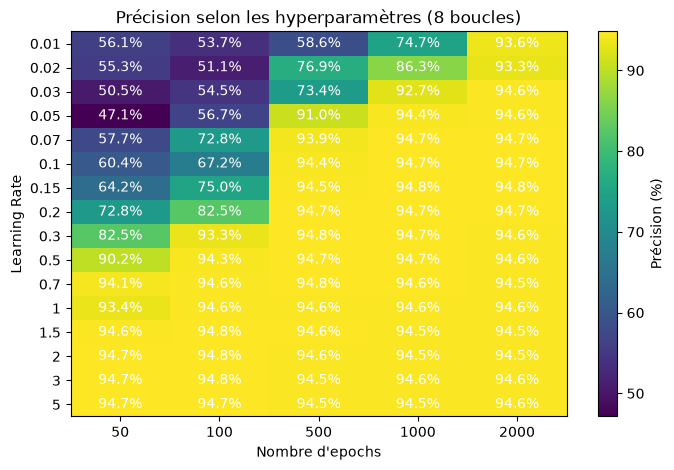

Meilleure précision : 94.82%
LR = 0.15, epochs = 2000


In [ ]:
learning_rates = [0.01, 0.02, 0.03, 0.05, 0.07, 0.1, 0.15, 0.2, 0.3, 0.5, 0.7, 1, 1.5, 2, 3, 5]
epochs = [50, 100, 500, 1000, 2000]
boucle = 8
data = []

for lr in learning_rates:
    for epoch in epochs:
        acc = []
        for k in range(boucle):
            mod = MLP([X.shape[1],2,2,1], 'sigmoide', LR=lr, epoch=epoch)
            mod.fit(X_train, y_train)
            yhat = mod.predict(X_test)
            yhat = np.where(yhat < 0.5, 0, 1)              # <-- seuillage ajouté
            acc.append(np.sum(yhat == np.array(y_test).reshape(-1,1)) / len(y_test) * 100)
            
        data.append([np.mean(acc), lr, epoch])

data = np.array(data)                                   # <-- conversion en tableau numpy

# Reshape pour obtenir : lignes = LR, colonnes = epochs
accuracies = data[:, 0].reshape(len(learning_rates), len(epochs))

fig, ax = plt.subplots(figsize=(8, 5))

image = ax.imshow(accuracies, cmap="viridis", aspect="auto")

ax.set_xticks(range(len(epochs)))
ax.set_xticklabels(epochs)
ax.set_yticks(range(len(learning_rates)))
ax.set_yticklabels(learning_rates)

ax.set_xlabel("Nombre d'epochs")
ax.set_ylabel("Learning Rate")
ax.set_title(f"Précision selon les hyperparamètres ({boucle} boucles)")

for i in range(len(learning_rates)):
    for j in range(len(epochs)):
        ax.text(j, i, f"{accuracies[i, j]:.1f}%",
                ha="center", va="center", color="white")

fig.colorbar(image, label="Précision (%)")
fig.savefig("precision_hyperparametres.png", dpi=300, bbox_inches="tight")
plt.show()

best = data[np.argmax(data[:, 0])]
print(f"Meilleure précision : {best[0]:.2f}%")
print(f"LR = {best[1]}, epochs = {int(best[2])}")



$ $